<a href="https://colab.research.google.com/github/c-lydia/operating_system/blob/main/robot_operating_system_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a id="docker-ros2-guide"></a>

# Robot Operating System 2

This chapter explains how ROS 2 programs communicate when they run in a Docker container, focusing on the container's interaction with the host machine. It serves as a module within a broader ROS 2 course, providing practical insights into running ROS 2 applications within a Dockerized environment and connecting them to host services.

The examples use **`koniot/dclab_docker:jazzy`**, a Linux container, ROS 2 Jazzy, and Fast DDS. The local copy was checked for the demo nodes, action tutorial, RViz, turtlesim, Gazebo command, and multicast CLI. It contains Ubuntu 24.04 and Fast DDS 2.14.6. The `humble` and `latest` tags also exist locally, but use the explicit `jazzy` tag for this chapter. For a Humble course or robot, adapt every image tag and ROS setup path together and check the distribution-specific discovery options.

Run Docker commands in a **host terminal**. On Windows, use a WSL 2 Bash terminal with Docker Desktop's integration enabled. Multiline commands use Bash/zsh continuation syntax. Commands labelled **inside the container** belong in the Linux shell opened with `docker exec`. The fenced commands are reference material, so opening this notebook does not launch containers or change your machine.

## Contents

1.  [Docker networking fundamentals](#docker-fundamentals): interfaces, addresses, bridge/host/none modes, NAT, and ports.
2.  [ROS 2 communication concepts](#ros2-communication): nodes, topics, services, parameters, actions, discovery, and QoS.
3.  [Running ROS 2 applications](#single-container-lab): starting a ROS 2 node, demonstrating basic communication.
4.  [DDS configuration](#dds-configuration): environment variables, and adapting for single-container scenarios.
5.  [GUI applications](#gui-applications): RViz/Gazebo, Windows WSLg and X servers, and remote desktops.
6.  [Troubleshooting](#network-troubleshooting): a diagnostic sequence with commands, expected evidence, and fixes.
7.  [Student practices and reference](#student-practices): command reference, and exercises with answers.

The primary practical target is running a ROS 2 application inside a container and ensuring it communicates correctly with the host or other services on the host machine. This chapter will explain the network path.

<a id="docker-fundamentals"></a>

## 1. Docker networking fundamentals


### 1.1 What a container sees

To understand how ROS 2 applications communicate within Docker, it's essential to grasp the container's isolated network view. A process in a container communicates via sockets, requiring an IP address, transport protocol (TCP/UDP), and a port. Each container typically has its own network namespace, providing dedicated interfaces, routes, sockets, and loopback. For a bridge-connected Linux container, this usually means a `lo` interface, an `eth0` interface, a private IP address, and a default route.

Consider a simple ROS 2 example: a camera publisher running inside a container. This publisher can bind a socket to its container's interfaces. Docker facilitates reaching this interface from the host, and ROS middleware handles discovery and message exchange over this path.

| Term | Meaning in this chapter |
| --- | --- |
| Interface | A connection point to a network |
| IP address | An address assigned to an interface |
| Port | A numbered endpoint used by a transport protocol |
| Route | A rule deciding where to send packets |
| DNS | Resolves names to addresses |
| Bridge | Connects interfaces on a virtual local network |
| NAT | Rewrites packet address/port information at a boundary |
| Loopback | Communication within the current network namespace |

**`localhost` depends on where the process runs.** In an ordinary bridge container, `localhost` refers to that container itself. If a web server runs in a container, for instance, asking the container to connect to `localhost:8080` means it will attempt to connect to its own local service. For communication with the host, the container should use the host's actual reachable IP address or the special `host.docker.internal` hostname.

### 1.2 The Docker Desktop boundary

Docker Desktop runs Linux containers within a Linux environment, often a virtual machine (e.g., WSL 2 on Windows, or a specific VM implementation on macOS). The container bridge network resides within this Linux environment. Docker Desktop provides crucial host integration features, including published ports and the special hostname `host.docker.internal`.

Generally, applications on your laptop (the host) should access a container service through a published port rather than attempting to connect directly to the container's private IP address, which is not directly routable from the host. Refer to [Docker Desktop networking](https://docs.docker.com/desktop/features/networking/) and [Desktop VM settings](https://docs.docker.com/desktop/settings-and-maintenance/settings/) for more details.



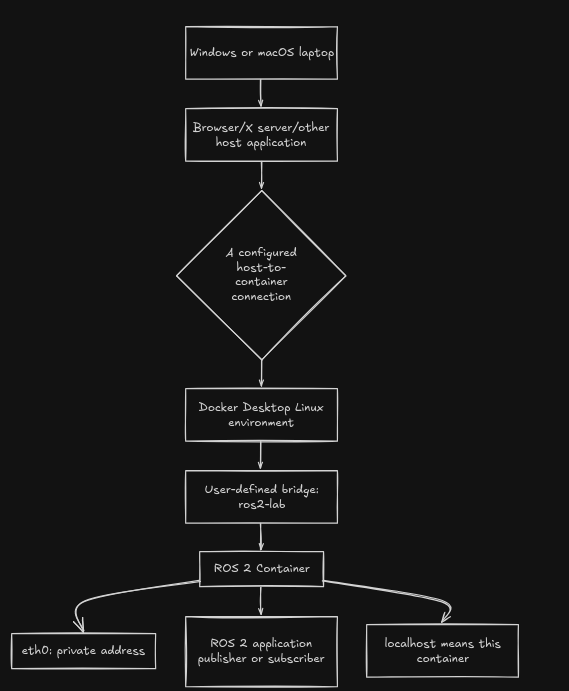

In [1]:
from IPython.display import Image
Image('host_container_traffic.png')

The diagram illustrates the path for host-to-container traffic as it crosses the Docker Desktop boundary. It's important to note that a setup designed for a container's internal processes requires explicit configuration to enable interaction with the host.

### 1.3 Default bridge and user-defined bridges

Without a network option, a typical Linux container joins Docker's default `bridge`. A user-defined bridge, such as `ros2-lab`, allows for better isolation and management. The focus of this lab will be on how a single container on a bridge network interacts with the host.

```bash
# Host terminal: inspect the default network.
docker network ls
docker network inspect bridge

# Create a project network; Docker chooses an available subnet.
docker network create --driver bridge ros2-lab
docker network inspect ros2-lab
```

NAT is chiefly relevant when traffic crosses its boundary. This distinction explains why DDS multicast can work between a container and the host if configured correctly, but discovery of a robot on the physical LAN might fail without specific considerations.

Docker DNS resolves container names to IP addresses. DDS discovery, on the other hand, finds ROS peers and endpoints. Resolving a container name proves that a name maps to an IP address, but it does not announce ROS topics, validate their message types, or establish compatible QoS.

### 1.4 Host networking

On native Linux Docker Engine, `--network host` uses the Docker host's network namespace. The container does not receive a separate network IP. This is useful when ROS nodes must use the Linux machine's reachable interfaces, but applications also share the host's port space. Two servers cannot both claim the same address/port combination.

**Docker Desktop 4.34 and later also offer host networking as an opt-in setting.** Its documented implementation supports TCP/UDP at layer 4, without giving a container direct access to the laptop's interfaces. Enable it under Docker Desktop's network settings when using it. Linux containers are required, and Enhanced Container Isolation is incompatible with this feature. Published-port options do not apply in host mode. See [host networking support and limitations](https://docs.docker.com/engine/network/drivers/host/).

```bash
# Using the koniot image described in Section 3:
docker run --rm -it --network host --entrypoint /bin/bash koniot/dclab_docker:jazzy
```

For ROS 2, treat Desktop host networking as a configuration to test. Its TCP/UDP support alone is insufficient evidence that your DDS multicast groups, interface selection, and advertised return addresses will work across a particular LAN. Test actual discovery and message delivery. Native Linux host networking and Desktop host networking have different interface behavior.


### 1.5 None and other network modes

`--network none` leaves a container with loopback networking. It is useful for offline file processing, such as analysing a recorded dataset without communicating with an external entity. ROS processes sharing that container can still use loopback if their middleware settings permit it.

```bash
docker run --rm -it --network none --entrypoint /bin/bash koniot/dclab_docker:jazzy
```

Overlay networks, Macvlan/ipvlan are generally used for more complex multi-host or specialized network administration scenarios and are not required for this single-container lab. Choose a network mode after identifying which processes need to reach each other and the host. The [Docker network driver overview](https://docs.docker.com/engine/network/drivers/) describes these options.

### 1.6 Port publishing: what `-p` does

The `-p` option is used to publish a container's port to the host. Its general form is `-p [HOST_IP:]HOST_PORT:CONTAINER_PORT[/PROTOCOL]`, where TCP is the default protocol. When publishing, the application inside the container must listen on a reachable interface, commonly `0.0.0.0` for IPv4, to accept connections.

Dockerfile `EXPOSE` instructions indicate intended ports but do not publish them; the `-p` option is necessary for actual port mapping. See [port publishing](https://docs.docker.com/engine/network/port-publishing/) and [Dockerfile EXPOSE](https://docs.docker.com/reference/dockerfile/#expose/).

For example, to start a temporary web server inside the container and make it accessible from the host:

```bash
docker run --rm --name ros-app-web --network ros2-lab -p 127.0.0.1:8080:8000 --entrypoint python3 koniot/dclab_docker:jazzy -m http.server 8000 --bind 0.0.0.0
```

After running this, you can open `http://localhost:8080` in your laptop's browser. The path for this connection is:

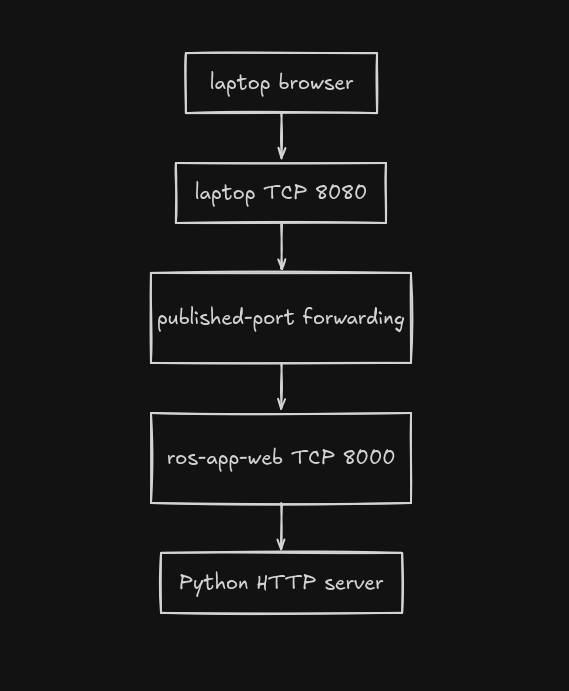

In [3]:
from IPython.display import Image
Image('port_pub.png')

| Example option | Meaning |
| --- | --- |
| `-p 127.0.0.1:8080:8000` | Publish container TCP 8000 for local host access on TCP 8080 |
| `-p 8080:8000` | Publish on host interfaces by default; reachability also depends on firewalls |
| `-p 127.0.0.1:11811:11811/udp` | Publish that UDP endpoint; a service must actually listen there |
| `-p 9000:9000/tcp -p 9000:9000/udp` | Configure the two distinct transport protocols separately |

It's important to remember that ROS 2/DDS typically uses several endpoints, and their ports vary depending on the middleware configuration, domain, and participants. Opening a single familiar port, such as UDP 7400, is usually insufficient for a complete ROS 2 network configuration. Publishing a discovery server port also does not automatically make the subsequent application data path reachable. This distinction is further elaborated in Section 4.

### 1.7 Reaching the host from a container

On Docker Desktop, `host.docker.internal` is the conventional name for reaching a service on the host. For example, a container's HTTP client can request `http://host.docker.internal:8000` if the host service is reachable there. Use the host service's port; this is a container-to-host connection.

On native Linux Engine, a common explicit setup is `--add-host host.docker.internal:host-gateway`. The host application must listen on an address reachable through that gateway. A host process listening only on host loopback may need a different binding. These mechanisms route application traffic; they do not turn Docker DNS into ROS graph discovery. See [container networking](https://docs.docker.com/engine/network/) and [Docker Desktop connection examples](https://docs.docker.com/desktop/features/networking/).

<a id="ros2-communication"></a>

## 2. Core ROS 2 communication concepts


### 2.1 Nodes and the ROS graph

A **node** is a fundamental software component in ROS 2, characterized by a name and defined communication interfaces. For example, a camera might be represented by a node that publishes image frames, a path planner by a node that computes routes, and a visualizer by a node that displays results. While a single container can run multiple processes, and a single process can host multiple nodes, there isn't a strict one-node/one-container relationship.

The **ROS graph** is a conceptual map illustrating the nodes within a ROS 2 system and their communication pathways. It's important to distinguish between a ROS node's name, a Docker container's name, and a network hostname—these are distinct identifiers. In this module, for instance, a container named `ros-app` (as defined in Section 3) will run the ROS node `/talker`. To query the ROS graph for information, you use ROS middleware commands; to query Docker for container information, you use Docker commands. See [ROS 2 nodes](https://docs.ros.org/en/jazzy/Concepts/Basic/About-Nodes.html) for more details.


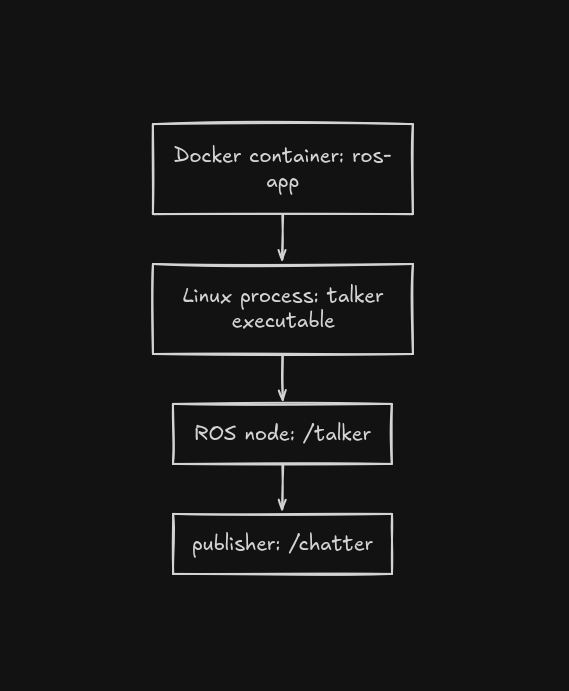

In [4]:
from IPython.display import Image
Image('node_ros_graph.png')

To interact with ROS nodes inside a container (after sourcing the ROS setup file):

```bash
ros2 node list
ros2 node info /talker
```

The first command lists all discovered node names, while the second provides detailed information about a specific node's publishers, subscribers, services, and other endpoints. Remember to allow sufficient time for DDS discovery to complete before interpreting an empty or incomplete result from these commands.

### 2.2 Topics: continuous publish/subscribe data

A **topic** in ROS 2 represents a named stream of data, associated with a specific message type. Publishers continuously write data samples to a topic, and subscribers receive matching samples asynchronously. For example, a camera node might publish raw image data on a topic like `/camera/image_raw` with the type `sensor_msgs/msg/Image`. Multiple subscribers, such as a visualizer, a data recorder, or an image processing algorithm, can independently subscribe to this topic.

It's typical for a publisher to continue sending data even if no subscriber is currently listening. A subscriber's ability to receive messages depends on its startup time, Quality of Service (QoS) settings, and the message's lifetime; simply joining a topic does not guarantee access to all historical messages. For more information, refer to the [ROS topic tutorial](https://docs.ros.org/en/jazzy/Tutorials/Beginner-CLI-Tools/Understanding-ROS2-Topics/Understanding-ROS2-Topics.html).

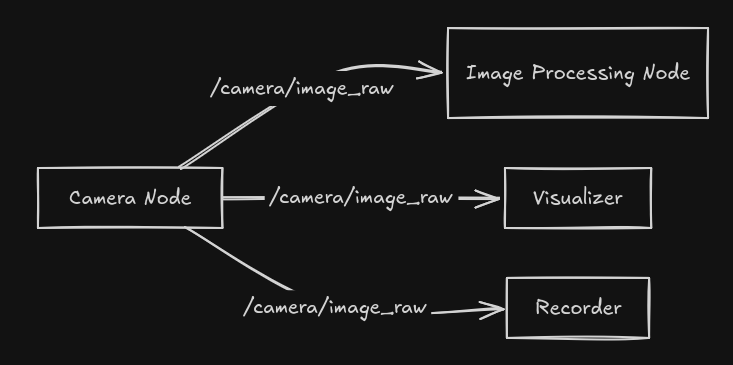

In [5]:
from IPython.display import Image
Image('topic.png')

Useful ROS 2 commands for inspecting topics (after sourcing ROS inside a container):

```bash
ros2 topic list -t
ros2 topic info /chatter --verbose
ros2 topic echo /chatter std_msgs/msg/String
ros2 topic hz /chatter
```

`list -t` displays topic names and their associated message types. `info --verbose` provides detailed information about endpoints and their QoS settings. `echo` creates a subscriber to print incoming messages, and `hz` estimates the message rate observed by its own subscription. At the networking layer, even with matching endpoints, a functional data transport is crucial. Default DDS configurations commonly use UDP and may leverage shared memory for efficient communication between suitable local participants. It's important to note that reliable ROS QoS can be achieved over UDP through middleware reliability mechanisms, and it does not inherently imply the use of TCP.

### 2.3 Services: a request followed by a response

A **service** in ROS 2 is designed for short, discrete operations that return a specific result, such as requesting a calibration value, resetting a counter, or performing a calculation like adding two integers. A client initiates communication by sending a request to a service server, which then processes the request and sends back a corresponding response. Application programming interfaces (APIs) can handle service calls either synchronously (waiting for the response before proceeding) or asynchronously (using callbacks or futures for non-blocking operations). For more information, refer to [ROS service concepts](https://docs.ros.org/en/jazzy/Concepts/Basic/About-Services.html) and [synchronous versus asynchronous clients](https://docs.ros.org/en/jazzy/How-To-Guides/Sync-Vs-Async.html).

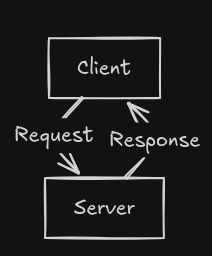

In [6]:
from IPython.display import Image
Image('service.png')

For the example service `/add_two_ints`, a request typically contains two integer arguments (e.g., `a` and `b`), and the response will contain their `sum`.

To interact with services (after sourcing ROS inside a container):

```bash
ros2 service list -t
ros2 interface show example_interfaces/srv/AddTwoInts
ros2 service call /add_two_ints example_interfaces/srv/AddTwoInts '{a: 2, b: 3}'
```

The `ros2 service call` command requires a running service server. When running the demo server from Section 3, the expected sum from the example call is `5`.

It's crucial to understand that ROS 2 services generally **do not** create a dedicated TCP connection solely due to their request/reply nature. The RMW (ROS Middleware) implementation transports the request and response using its configured transport, which in this Fast DDS lab, can be UDP. A request timeout can indicate a failure in discovery, a problem with the return path, or an issue with the server application's ability to process the request.

### 2.4 Parameters: configuration owned by a node

A **parameter** is a named value associated with a node. Examples include a camera's frame rate or a detector's threshold. A node determines which parameters exist, their types and constraints, and whether they may change while running.

By default, ROS nodes commonly expose parameter services for remote queries and updates. Parameter changes can also produce messages on `/parameter_events`. There is no single ROS 1-style global parameter server that Docker must expose. If parameter service creation is disabled by the application, the CLI cannot assume those services exist. See [ROS 2 parameters](https://docs.ros.org/en/jazzy/Concepts/Basic/About-Parameters.html).

```bash
ros2 param list /talker
ros2 param get /talker use_sim_time
ros2 param describe /talker use_sim_time
ros2 param set /talker use_sim_time false
```

For a running demo talker with its usual parameter services, these commands inspect and set its time-source selection. `false` selects ordinary system time. Setting it to `true` means the node expects ROS simulation time from `/clock`, which is useful in simulation but confusing when no clock publisher exists.

Changing a container environment variable after a node starts does not rewrite that node's existing DDS configuration. Environment variables are read by processes at initialization; ROS parameters are an application-level interface with their own rules.


### 2.5 Actions: a goal, feedback, cancellation, and a result

An **action** fits operations that take time, such as navigating to a pose. A client submits a goal, receives acceptance or rejection, monitors feedback, and eventually obtains a result. Cancellation is part of the protocol; the server must implement the intended cancellation behavior.

An action uses several ROS endpoints: services for sending goals, requesting results, and cancellation, plus topics for feedback and status. Therefore a partly reachable system can accept a goal yet fail to deliver feedback or a result. A successful request alone does not prove the entire action works. See [ROS action design](https://design.ros2.org/articles/actions.html).


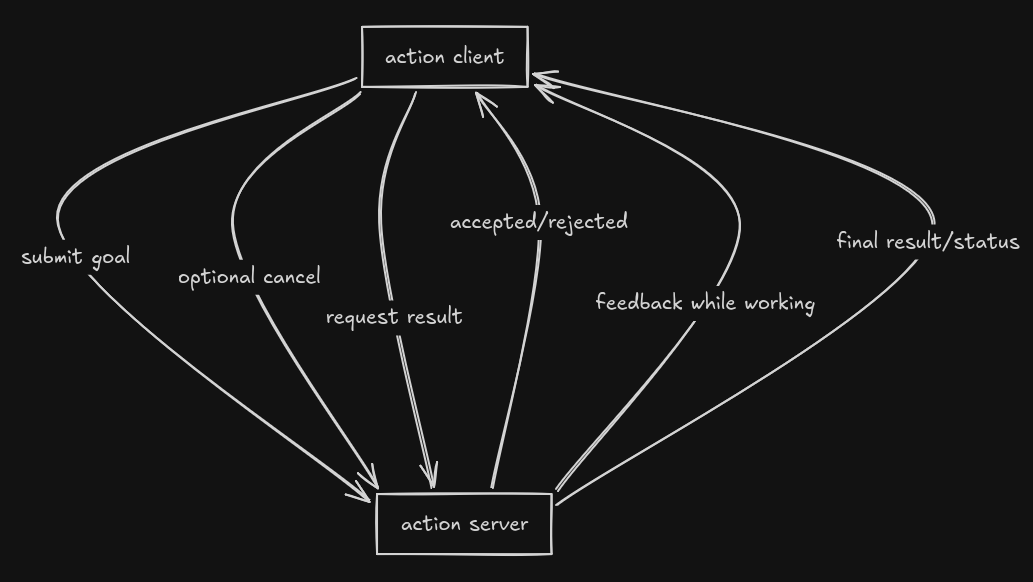

In [7]:
from IPython.display import Image
Image('actions.png')

```bash
ros2 action list -t
ros2 action info /fibonacci
ros2 action send_goal /fibonacci action_tutorials_interfaces/action/Fibonacci '{order: 5}' --feedback
```

Section 3 supplies the demo action server. A navigation stack would instead use its own action name and type; the action above only computes a number sequence.

### 2.6 RMW, DDS, discovery, and data transfer

ROS client libraries, such as `rclcpp` (for C++) and `rclpy` (for Python), interact with a middleware abstraction layer known as **RMW (ROS Middleware)**. In this chapter, we primarily use `rmw_fastrtps_cpp`, which leverages **Fast DDS** as its underlying Data Distribution Service (DDS) implementation. It's important to note that other RMW implementations exist, including alternative DDS implementations and non-DDS options. When configuring your system, ensure that DDS-specific settings are applied to your chosen DDS middleware. For a comprehensive overview of ROS middleware implementations, consult [ROS middleware implementations](https://docs.ros.org/en/jazzy/Concepts/Intermediate/About-Different-Middleware-Vendors.html).

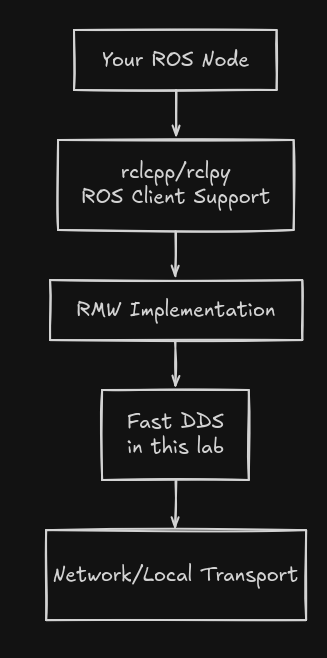

In [8]:
from IPython.display import Image
Image('dds.png')

When debugging ROS 2 communication, two distinct stages are critical to consider:

1.  **Discovery:** During this stage, middleware participants identify each other and learn about available endpoints, including topic names, message types, and Quality of Service (QoS) policies. Default DDS discovery often utilizes multicast as a primary mechanism for this process.
2.  **Data Delivery:** Once discovery is complete and compatible endpoints are found, this stage involves the actual exchange of application data samples or requests/replies using the configured transports and reachable advertised addresses.

Multicast communication involves sending data to a group of recipients, while unicast sends data to a single, specific destination. Various network components—such as routers, virtual machine boundaries, Wi-Fi access points, or Virtual Private Networks (VPNs)—can handle these two types of communication differently. While explicit peers can reduce the reliance on multicast for discovery, they do not inherently resolve issues with unreachable data addresses that might be advertised after the discovery phase.

<a id="single-container-lab"></a>

## 3. Running ROS 2 applications in a single container

This section demonstrates how to run ROS 2 applications within a single Docker container and establish basic communication.

### 3.1 Prepare the koniot image and network

The local `koniot/dclab_docker:jazzy` image already contains the programs required for this exercise. On a different machine, obtain the same image tag from the course's image source. If it is available from your registry account, the command is `docker pull koniot/dclab_docker:jazzy`. Registry access and CPU architecture support depend on the published image.

In a host terminal, check the local image:

```bash
docker image inspect koniot/dclab_docker:jazzy --format '{{.Os}}/{{.Architecture}}'
docker image inspect koniot/dclab_docker:jazzy --format '{{json .RepoDigests}}'
```

The first command reports the architecture. This matters on an Apple Silicon Mac: an amd64-only image needs emulation and can run more slowly. Prefer the course's matching architecture build when one exists. A tag can change; an available repository digest identifies the image content more precisely.

Create `ros2-lab` if you did not create it in Section 1:

```bash
docker network create --driver bridge ros2-lab
```

If Docker says this network already exists, inspect it and reuse it for the exercise. Start a persistent container:

```bash
docker run -d --rm --name ros-app --network ros2-lab \
  -e ROS_DOMAIN_ID=42 -e RMW_IMPLEMENTATION=rmw_fastrtps_cpp \
  -e ROS_AUTOMATIC_DISCOVERY_RANGE=SUBNET \
  --entrypoint /bin/bash koniot/dclab_docker:jazzy -c 'exec sleep infinity'
```

`-d` runs in the background. `--rm` removes the container when it stops. `--name` gives it a stable lab name, and `--network` chooses the shared bridge. The `-e` options establish the process environment inherited by later `docker exec` commands. An explicit Bash entrypoint gives this exercise a predictable starting process; each ROS shell will source the setup file explicitly.

### 3.2 Verify container network connectivity

```bash
docker ps --filter name=ros-app
docker network inspect ros2-lab
```

The network inspection should show `ros-app` with an address in the specified subnet. This establishes network membership before any ROS application runs.

The checked koniot image does not include the `ip` and `ping` commands, so these exercises use Docker inspection. If you install `iproute2` and `iputils-ping` in a separate teaching image, you can additionally inspect `ip address`, `ip route`, and `ping -c 3 host.docker.internal`. An absent diagnostic command is different from a failed network test.

### 3.3 Start a ROS 2 publisher and subscriber within the container

In a **host terminal**, open the container:

```bash
docker exec -it ros-app bash
```

Then run **inside the container**: (Publisher)

```bash
source /opt/ros/jazzy/setup.bash
ros2 run demo_nodes_cpp talker
```

In a **second host terminal**, open another shell in the container:

```bash
docker exec -it ros-app bash
```

Then run **inside that shell**: (Subscriber)

```bash
source /opt/ros/jazzy/setup.bash
ros2 run demo_nodes_cpp listener
```

The talker should repeatedly report publishing a `Hello World` string. After discovery, the listener should repeatedly report receiving it. Exact timestamps and counters vary. This demonstrates actual application data delivery within the same container.

In a **third host terminal**, open another shell in the container:

```bash
docker exec -it ros-app bash
```

Run **inside that shell**:

```bash
source /opt/ros/jazzy/setup.bash
ros2 node list
ros2 topic list -t
ros2 topic info /chatter --verbose
ros2 topic echo /chatter std_msgs/msg/String --once
```

Look for `/talker`, `/listener`, the `/chatter` topic with `std_msgs/msg/String`, and one received string. You may see other standard topics, such as `/parameter_events` and `/rosout`.

`docker exec` starts a new process. It does not rerun an image's entrypoint or inherit an `export` typed in an unrelated interactive shell. Source ROS in each new shell and provide any additional experiment-specific variables there. See the [Docker exec reference](https://docs.docker.com/reference/cli/docker/container/exec/).

### 3.4 Exercise services, parameters, and actions

Keep the talker running to inspect its parameters from the third shell in B:

```bash
ros2 param list /talker
ros2 param get /talker use_sim_time
ros2 param set /talker use_sim_time false
```

For the service test, open an additional sourced shell in A and start:

```bash
ros2 run demo_nodes_cpp add_two_ints_server
```

From a sourced shell in B:

```bash
ros2 service call /add_two_ints example_interfaces/srv/AddTwoInts '{a: 2, b: 3}'
```

The response should contain `sum=5` or an equivalent formatted field. This checks both the request and response path.

Stop the service server with Ctrl+C, then start the action server in A:

```bash
ros2 run action_tutorials_cpp fibonacci_action_server
```

From B:

```bash
ros2 action send_goal /fibonacci action_tutorials_interfaces/action/Fibonacci '{order: 5}' --feedback
```

The client should report a goal response, intermediate sequence feedback, and a final result. The checked Jazzy action server advertises `action_tutorials_interfaces/action/Fibonacci`; use the type shown by `ros2 action list -t` when adapting to another image. Stop the action server with Ctrl+C after the exercise. These examples run only demonstration computations.


### 3.4 Exercise services, parameters, and actions within the container

Keep the talker running to inspect its parameters from the third shell:

```bash
ros2 param list /talker
ros2 param get /talker use_sim_time
ros2 param set /talker use_sim_time false
```

For the service test, open an additional sourced shell in the container and start the server:

```bash
ros2 run demo_nodes_cpp add_two_ints_server
```

From a sourced shell in the container:

```bash
ros2 service call /add_two_ints example_interfaces/srv/AddTwoInts '{a: 2, b: 3}'
```

The response should contain `sum=5` or an equivalent formatted field. This checks both the request and response path.

Stop the service server with Ctrl+C, then start the action server in the container:

```bash
ros2 run action_tutorials_cpp fibonacci_action_server
```

From another sourced shell in the container:

```bash
ros2 action send_goal /fibonacci action_tutorials_interfaces/action/Fibonacci '{order: 5}' --feedback
```

The client should report a goal response, intermediate sequence feedback, and a final result. The checked Jazzy action server advertises `action_tutorials_interfaces/action/Fibonacci`; use the type shown by `ros2 action list -t` when adapting to another image. Stop the action server with Ctrl+C after the exercise. These examples run only demonstration computations.

### 3.5 Integrating with a robot or external systems


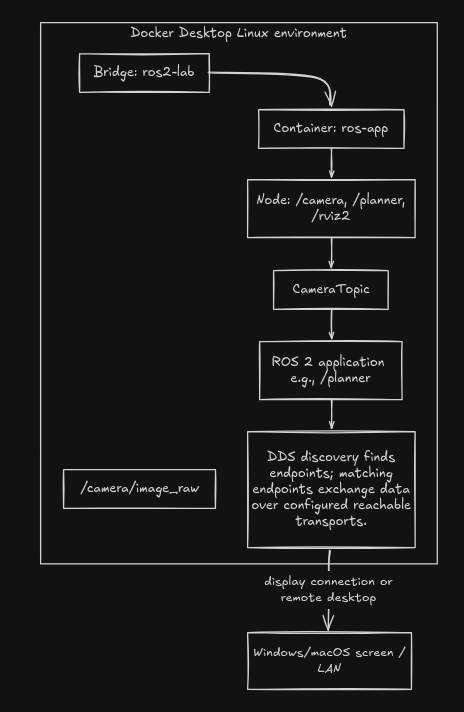

In [9]:
from IPython.display import Image
Image('integration.png')

This diagram illustrates a typical application design. If the ROS 2 application within the container needs to communicate with an external physical robot or another ROS 2 system located on the Local Area Network (LAN), additional networking configuration beyond the basic setup will be necessary. The primary focus of this section is on demonstrating the functionality of ROS 2 applications *within* a single container. Establishing connections to a physical robot or other external systems typically involves bridging the Docker network to the host's physical network, a concept further explored in Section 4.7.

<a id="dds-configuration"></a>

## 4. DDS configuration for Docker Desktop

This section covers DDS configuration relevant to a single container's interaction with the host and potential external systems.

### 4.1 Establish which boundary is failing

When troubleshooting, it's crucial to first identify precisely which network boundary is causing communication to fail. Start with the working single-container lab and consider the communication path. A multicast packet sent by a container for an application running on the host, or intended for a robot on a Wi-Fi network, will traverse different network paths. Factors such as Docker Desktop's host integration, Network Address Translation (NAT), routing configurations, and how the LAN handles multicast traffic will all affect the latter path.

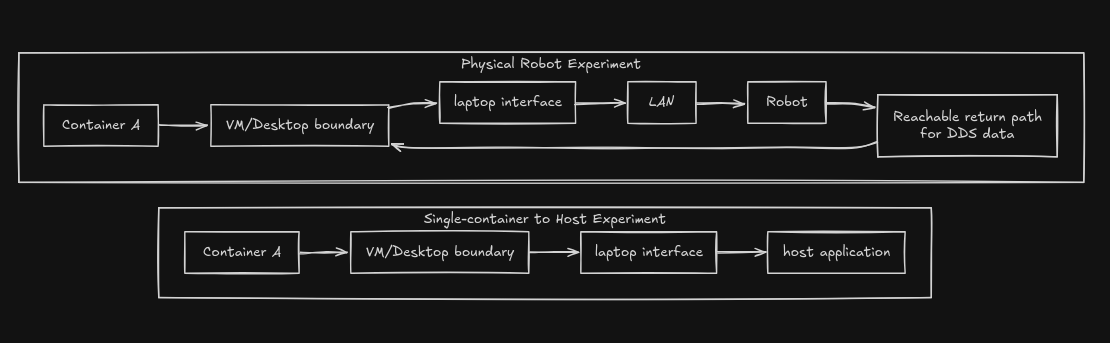

In [10]:
from IPython.display import Image
Image('experiment.png')

While explicit peers or a discovery server can help participants locate each other, for a single container, the main concern is whether its DDS advertisements can reach the host (and vice versa). Both communicating entities still require reachable data locators, which are the addresses and ports that DDS advertises for actual data exchange. It's important to note that a robot typically cannot send data directly to a laptop's private Docker subnet without specific routing configurations or an appropriate data relay architecture.

### 4.2 Essential environment variables

| Variable | Purpose | How this chapter uses it |
| --- | --- | --- |
| `ROS_DOMAIN_ID` | Separates DDS domains used by ROS participants | `42` for all lab nodes |
| `RMW_IMPLEMENTATION` | Selects an installed middleware implementation | `rmw_fastrtps_cpp` |
| `ROS_LOCALHOST_ONLY` | Legacy ROS locality control, common in older distributions | Unset for these Jazzy examples; `1` can prevent container-to-host communication |
| `ROS_AUTOMATIC_DISCOVERY_RANGE` | Controls automatic discovery for supported RMW implementations | `SUBNET` for the baseline; `LOCALHOST` with explicit peers; `SYSTEM_DEFAULT` for specialized configurations |
| `ROS_STATIC_PEERS` | Semicolon-separated peer addresses/names | Used for explicit host-to-container interaction |
| `ROS_DISCOVERY_SERVER` | Configures Fast DDS discovery server addresses | Used only in specialized configurations |
| `FASTRTPS_DEFAULT_PROFILES_FILE` | Points Fast DDS 2.x to an XML profile | Used for advanced DDS customization |

All communicating lab nodes use the same domain. A domain ID is logical separation, not authentication or encryption. DDS port calculations also depend on the domain and participant IDs, so choose domain values with your platform's port ranges in mind. `42` is a convenient teaching choice.

For Jazzy's supported DDS RMW implementations, `SUBNET` permits discovery through reachable multicast; `LOCALHOST` restricts automatic discovery to the local host while configured static peers can extend it. `SYSTEM_DEFAULT` leaves discovery configuration to the middleware. The documented `OFF` setting disables discovery and should not be used for these exercises. Older distributions such as Humble need their corresponding configuration instructions. See [Jazzy discovery controls](https://docs.ros.org/en/jazzy/Tutorials/Advanced/Improved-Dynamic-Discovery.html).

In a container, setting `ROS_LOCALHOST_ONLY` can prevent communication with the host even though both run on the same laptop. The resulting missing endpoints affect topics, service calls, parameter requests, and actions.

Configure variables **before starting the ROS process**. Restart the ROS CLI daemon when you change the middleware, domain, or discovery configuration used by diagnostic commands:

```bash
ros2 daemon stop
ros2 daemon start
```

Run the stop command under the old environment if changing domains, then set the new variables and start it again. The container can have its own daemon. Changing your host terminal's variables does not reconfigure a daemon or node already running in a container.

### 4.3 Testing multicast from container to host

With `ros-app` on `ros2-lab`, stop its demo nodes temporarily. In a sourced shell **inside ros-app**, run:

```bash
ros2 multicast send
```

On the **host terminal**, ensure you have ROS 2 installed and sourced, then run:

```bash
ros2 multicast receive
```

If the host receives the message, it indicates basic multicast connectivity between the container and the host. Repeat with the host sending and the container receiving. This tests the CLI's multicast group/port across the selected path; it does not prove every DDS endpoint or QoS combination works. If it succeeds but the ROS application fails, inspect ROS configuration next. See the [ROS multicast CLI](https://github.com/ros2/ros2cli/tree/jazzy/ros2multicast).

### 4.4 Explicit unicast peers for container-host communication

This is a separate configuration experiment for when multicast is not desired or not working. Stop the ROS applications and any existing ROS CLI daemon in the container first.

To allow the container to explicitly find a ROS application on the host, you would set `ROS_STATIC_PEERS` to the host's IP address. Similarly, a host application could set the container's IP as a static peer. This requires knowing the specific IP addresses, which can change in Docker.

Alternatively, you can use `host.docker.internal` from the container as a peer if the host has a ROS application listening. Example:

In the **container** (sourced shell):

```bash
unset ROS_LOCALHOST_ONLY ROS_DISCOVERY_SERVER FASTRTPS_DEFAULT_PROFILES_FILE
export ROS_DOMAIN_ID=42
export RMW_IMPLEMENTATION=rmw_fastrtps_cpp
export ROS_AUTOMATIC_DISCOVERY_RANGE=LOCALHOST
export ROS_STATIC_PEERS='host.docker.internal'
ros2 run demo_nodes_cpp talker
```

On the **host** (sourced ROS environment, potentially using `--network host` for the host ROS application if needed):

```bash
unset ROS_LOCALHOST_ONLY ROS_DISCOVERY_SERVER FASTRTPS_DEFAULT_PROFILES_FILE
export ROS_DOMAIN_ID=42
export RMW_IMPLEMENTATION=rmw_fastrtps_cpp
export ROS_AUTOMATIC_DISCOVERY_RANGE=LOCALHOST
# This assumes your host has an IP in the Docker network's subnet or you use specific IP
# For simplicity, if the host ROS node is just on host network, it might still find it
# In a more complex scenario, you might need to find the container's IP and use it here
ros2 run demo_nodes_cpp listener
```

This configuration replaces automatic off-host peer discovery for this experiment. These settings do not establish routes through NAT, but rely on `host.docker.internal` or direct IP if known. See the [static-peer example](https://docs.ros.org/en/jazzy/Tutorials/Advanced/Improved-Dynamic-Discovery.html#examples).

### 4.7 Connecting to a robot on the physical LAN

Write down the actual path before changing ports. The robot needs to reach whatever addresses the laptop-side middleware advertises, and the laptop needs to reach the robot's advertised endpoints. Check that the Wi-Fi network permits device-to-device traffic and that multicast is permitted where you expect it. Guest-network isolation can prevent communication even when both devices access the internet.

For a teaching setup, useful arrangements include running the ROS graph on a Linux robot/lab machine and displaying its desktop remotely, or using native Linux host networking with matching ROS settings. A Desktop-based distributed graph can also be engineered with appropriate routing, DDS configuration, or a data relay. Its configuration depends on the actual interfaces, middleware, and network policy.

Publishing `11811/udp` only exposes a discovery-server endpoint (if one is configured). It does not relay `/camera/image_raw`, service responses, or action feedback through that port. Similarly, opening an arbitrary large UDP range does not correct an unreachable address inside DDS discovery metadata. Verify the bidirectional data path with a small topic and a service before adding image streams or robot-control interfaces.

## 5. GUI applications

### 5.1 Separate ROS data from the display connection

RViz is a powerful tool that functions as both a ROS application and a graphics application. To operate correctly, it requires several components to be in place: ROS discovery, compatible subscriptions to ROS topics, appropriate transform configurations, and a functional display/graphics stack. Similarly, Gazebo, a robot simulator, adds its own simulation processes, and specific transport and rendering requirements. Merely installing RViz or Gazebo does not automatically configure all these underlying communication and rendering paths.

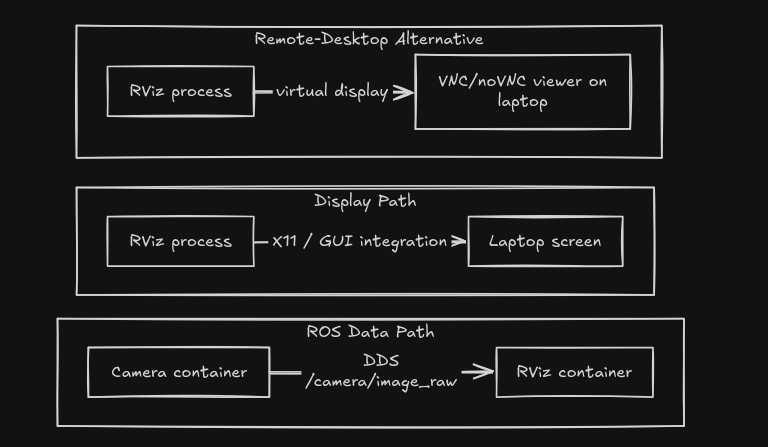

In [11]:
from IPython.display import Image
Image('display_ros_data.png')

If the RViz window successfully opens but no data appears (e.g., no image from a camera topic), the first steps for diagnosis should be to inspect the topic names, Quality of Service (QoS) settings, transform tree, and the fixed frame within RViz itself. If, however, the RViz window fails to open entirely, the primary focus should shift to testing the display connection before investigating DDS settings. In X11 terminology, RViz functions as an **X client**, and the component responsible for managing the screen is the **X server**. For example, a `DISPLAY=host.docker.internal:0` setting indicates an X server running on the Docker Desktop host at display number 0. For a TCP X11 connection, display 0 conventionally uses TCP port 6000. This represents an *outgoing* connection from the container to a host service, meaning that publishing container port 6000 is not the required direction for this communication. For more details, consult the [X.Org display syntax](https://www.x.org/releases/current/doc/man/man7/X.7.xhtml).

### 5.2 Windows with WSLg

WSLg integrates Linux X11/Wayland applications with supported Windows/WSL 2 installations. Check `wsl --version` and `wsl -l -v` in PowerShell and verify that ordinary Linux GUI applications work inside your WSL distribution first. Microsoft's [WSL GUI setup guide](https://learn.microsoft.com/en-us/windows/wsl/tutorials/gui-apps) lists the Windows and graphics-driver prerequisites.

For the X11 route below, run Docker from the integrated WSL Bash terminal. Check the local display and WSLg socket directory:

```bash
printf '%s\n' "$DISPLAY"
ls -ld /mnt/wslg/.X11-unix
ls -l /mnt/wslg/.X11-unix
```

On installations where Docker Desktop's WSL integration can bind-mount these sockets, this container command tests X server access:

```bash
docker run --rm --network ros2-lab \
  -e DISPLAY="${DISPLAY:-:0}" \
  --mount type=bind,src=/mnt/wslg/.X11-unix,dst=/tmp/.X11-unix \
  --entrypoint xdpyinfo koniot/dclab_docker:jazzy
```

If it prints display information, start RViz through the same socket:

```bash
docker run --rm --name ros-rviz --network ros2-lab \
  -e ROS_DOMAIN_ID=42 -e RMW_IMPLEMENTATION=rmw_fastrtps_cpp \
  -e ROS_AUTOMATIC_DISCOVERY_RANGE=SUBNET \
  -e DISPLAY="${DISPLAY:-:0}" -e QT_X11_NO_MITSHM=1 \
  -e LIBGL_ALWAYS_SOFTWARE=1 \
  --mount type=bind,src=/mnt/wslg/.X11-unix,dst=/tmp/.X11-unix \
  --entrypoint /bin/bash koniot/dclab_docker:jazzy \
  -c 'source /opt/ros/jazzy/setup.bash && exec rviz2'
```

This requests software rendering as an initial diagnostic configuration; it can be slow. Accelerated rendering needs the appropriate device access and graphics libraries inside the container in addition to working WSLg on the host. Mounting a display socket alone does not supply that GPU integration.

The socket source must exist and be visible to the Docker backend. If the bind mount fails or `xdpyinfo` cannot connect, check Docker Desktop's integration for that WSL distribution. Do not substitute a Windows directory that has no Linux display socket. Use the TCP X-server route below or a remote desktop when the socket route is unsuitable. These GUI routes depend on the actual Windows/WSLg installation and require local validation.


### 5.3 Windows with a separate X server

VcXsrv or X410 can supply an X server when WSLg is unavailable or a TCP display route is preferred. Use the selected server's documented authentication and client-access settings. Configure its TCP listener and allow only the intended Docker/WSL traffic through the Windows firewall. A working DNS lookup of `host.docker.internal` alone does not prove the X server is listening or authorizing the client.

For a **VcXsrv setup using an Xauthority cookie**, the following is a concrete file-based approach. It requires `xauth` and `openssl` in the WSL host shell. Create these files in a dedicated lab directory accessible from Windows:

```bash
umask 077
touch x11-source.auth docker-x11.auth
xauth -f x11-source.auth add :0 MIT-MAGIC-COOKIE-1 "$(openssl rand -hex 16)"
xauth -f x11-source.auth nlist :0 | sed 's/^..../ffff/' | xauth -f docker-x11.auth nmerge -
chmod 600 x11-source.auth docker-x11.auth
```

The second file contains the cookie with a wildcard address family so it can match the display name used inside the container. Configure VcXsrv to use this same `docker-x11.auth` file via its `-auth` option, using its Windows-visible path, and permit the required TCP listener. Keep access control enabled. The X server and the client must have the same cookie; merely creating a client file cannot authorize a server that uses a different one. The [VcXsrv project](https://sourceforge.net/projects/vcxsrv/) supplies the server, and [X.Org xauth](https://www.x.org/releases/current/doc/man/man1/xauth.1.xhtml) documents authorization files.

The koniot image uses UID 999 in the checked copy. To let a private host-owned cookie file remain readable without loosening its permissions, run this GUI container as the WSL user's UID/GID. Set a writable home directory for GUI configuration:

```bash
docker run --rm --name ros-rviz --network ros2-lab \
  --user "$(id -u):$(id -g)" -e HOME=/tmp \
  -e ROS_DOMAIN_ID=42 -e RMW_IMPLEMENTATION=rmw_fastrtps_cpp \
  -e ROS_AUTOMATIC_DISCOVERY_RANGE=SUBNET \
  -e DISPLAY=host.docker.internal:0 -e XAUTHORITY=/tmp/docker-x11.auth \
  -e QT_X11_NO_MITSHM=1 -e LIBGL_ALWAYS_SOFTWARE=1 \
  --mount "type=bind,src=$PWD/docker-x11.auth,dst=/tmp/docker-x11.auth,readonly" \
  --entrypoint /bin/bash koniot/dclab_docker:jazzy \
  -c 'source /opt/ros/jazzy/setup.bash && xdpyinfo >/dev/null && exec rviz2'
```

If your selected X server uses a different authentication method, substitute its documented configuration. Avoid globally disabling X access control with `xhost +` or a blanket “disable access control” setting; it exposes the display to additional clients. This TCP route does not require a `/tmp/.X11-unix` socket mount.


### 5.5 VNC, noVNC, and NoMachine

A remote desktop keeps the X server and ROS GUI applications in a Linux environment. VNC transports that desktop to a client; noVNC supplies a browser client through a WebSocket gateway; NoMachine provides another remote-desktop stack. This can make the display path easier to manage across Windows and macOS. See the [TigerVNC project](https://tigervnc.org/), [noVNC documentation](https://novnc.com/info.html), and [NoMachine documentation](https://www.nomachine.com/documents).

The base image's presence of RViz does not establish that a remote-desktop server is installed or running. A course image derived from `koniot/dclab_docker:jazzy` must additionally configure the selected server, a virtual display, authentication, and its startup command. Check the configured listening ports rather than assuming every image uses the same ones.

For a server deliberately configured for **VNC display `:1` on TCP 5901**, the Docker publication option is:

```text
-p 127.0.0.1:5901:5901
```

For a noVNC gateway deliberately configured on **TCP 6080**, it is:

```text
-p 127.0.0.1:6080:6080
```

These are options to add to that configured image's `docker run` command. They do not install or start VNC/noVNC. With the second mapping, open `http://localhost:6080` on the laptop and authenticate to the configured desktop. Use the server's configured port for NoMachine as well.

Keep the remote-desktop ROS container on the same project bridge as the ROS nodes. Only its display server needs the host-facing port mapping for local viewing. For remote access from another machine, arrange an authenticated encrypted access path suitable for the lab.


### 5.6 RViz and Gazebo checks after a window opens

For RViz, select an existing fixed frame and add the intended display type and topic. Inspect topic QoS and the transform tree when an image or point cloud remains absent. A “No transform” message is evidence about frames, timestamps, or `/tf` delivery, rather than proof of a broken X connection. See the [RViz user guide](https://docs.ros.org/en/jazzy/Tutorials/Intermediate/RViz/RViz-User-Guide/RViz-User-Guide.html).

Gazebo's GUI and simulation server may communicate through Gazebo Transport; ROS data can require an appropriate `ros_gz_bridge` configuration. `ROS_DOMAIN_ID` alone does not configure Gazebo's own discovery or create that bridge. First verify the simulation can run, then verify the relevant ROS topics. See [ROS/Gazebo integration](https://gazebosim.org/docs/harmonic/ros2_integration/).

Large 3D scenes, software rendering, and architecture emulation can consume substantial CPU and memory. Start with a small scene or one RViz display, measure resource use, and add complexity after the basic paths work.


<a id="network-troubleshooting"></a>

## 6. Troubleshooting common ROS 2 Docker issues

This section focuses on troubleshooting ROS 2 applications running within a single Docker container, especially regarding its interaction with the host.

### 6.1 Work from the failing layer

When troubleshooting ROS 2 applications in Docker, it's most effective to start by isolating the smallest failing example and clearly define its expected outcome. For instance, diagnosing "the listener receives a string from the talker within the same container" is far more specific and actionable than simply stating "Docker networking works." Follow this diagnostic sequence, moving from fundamental issues to more application-specific concerns:

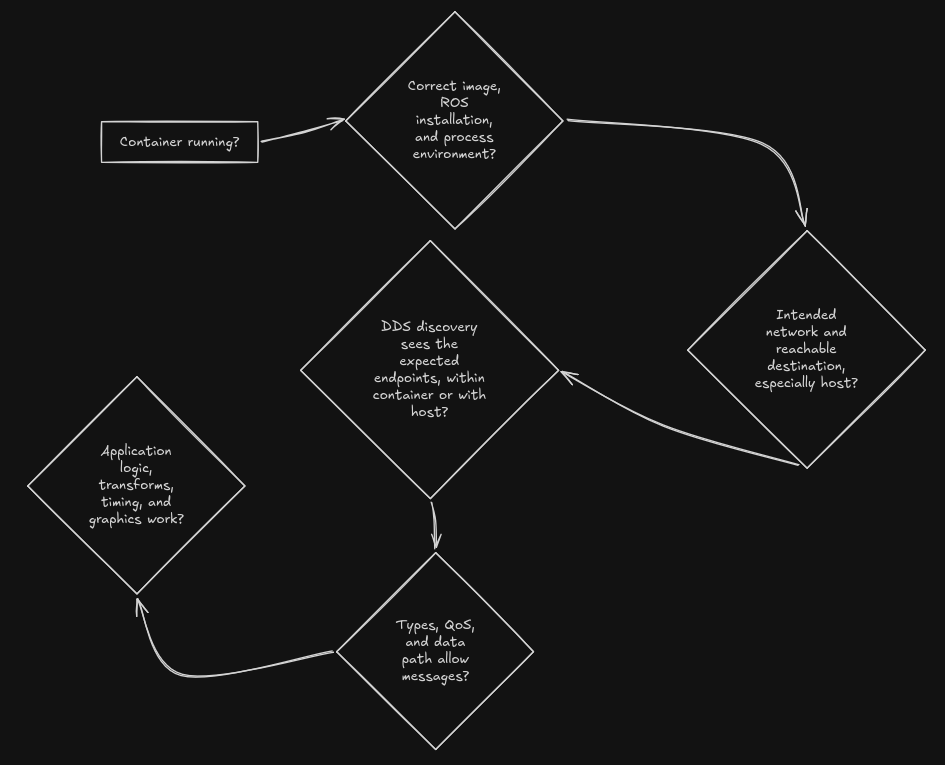

In [13]:
from IPython.display import Image
Image('failing_layer.png')

The key principle is to change only one configuration parameter at a time. After each change, restart any processes that read that configuration, and then re-run the same small test. Avoid the temptation to simultaneously apply multiple configurations, such as XML profiles, discovery-server settings, and static peers, without first confirming the functionality of each mechanism independently.

### 6.2 Container and environment checks

From the host:

```bash
docker ps -a --filter name=ros-app
docker logs --tail 50 ros-app
docker network inspect ros2-lab
docker inspect ros-app --format '{{json .NetworkSettings.Networks}}'
```

The manual lab container runs `sleep infinity`, so its Docker logs can be empty while commands launched through `docker exec` print in their own terminals. If you were running a Compose version (not in this simplified lab), `docker compose logs` would contain the program's output.

Inside the failing container shell:

```bash
source /opt/ros/jazzy/setup.bash
printf 'ROS distribution: %s
' "$ROS_DISTRO"
python3 -c "import os; keys=['ROS_DOMAIN_ID','RMW_IMPLEMENTATION','ROS_LOCALHOST_ONLY','ROS_AUTOMATIC_DISCOVERY_RANGE','ROS_STATIC_PEERS','ROS_DISCOVERY_SERVER','ROS_SUPER_CLIENT','FASTRTPS_DEFAULT_PROFILES_FILE']; print('\n'.join(k+'='+os.environ.get(k,'<unset>') for k in keys))"
ros2 pkg prefix rmw_fastrtps_cpp
```

Compare the results. If a process was launched by another shell, these commands describe the current shell; inspect its launch configuration and restart it with the intended variables. A missing RMW package requires using an installed middleware or adding the package to the image, not changing network ports.

### 6.3 Reachability and discovery checks

From the host, verify Docker DNS for `host.docker.internal` if needed:

```bash
docker exec ros-app python3 -c "import socket; print(socket.gethostbyname('host.docker.internal'))"
```

If name resolution fails, confirm Docker Desktop setup. If it succeeds, proceed to the multicast test in Section 4 and then the talker/listener if trying to connect to a host ROS application. `ping`, if installed, tests ICMP; successful ICMP alone does not test DDS's UDP sockets.

For graph inspection in a sourced container shell:

```bash
ros2 daemon stop
ros2 node list --no-daemon
ros2 topic list -t
ros2 topic info /chatter --verbose
```

Use the same discovery settings as the intended ROS graph. In discovery-server mode (if used for host communication), apply the super-client configuration for graph inspection. If the CLI results look stale after changing a domain, remember that a daemon started under the old domain may still be running there. See [the ROS CLI daemon](https://docs.ros.org/en/jazzy/Concepts/Basic/About-Command-Line-Tools.html).

### 6.4 Match symptoms to evidence

| Symptom | What to inspect next | Why it matters |
| --- | --- | --- |
| Docker reports a container-name conflict | `docker ps -a` and the chosen name | An older lab container may still own it |
| `ros2: command not found` | Image tag and sourced setup file | The executable search environment is wrong or the installation is missing |
| `host.docker.internal` cannot be resolved from container | Docker Desktop setup and network mode | Name resolution depends on the Docker network |
| ROS nodes are absent (e.g., from host `ros2 node list`) | Domain, RMW, locality settings, discovery path | Endpoints cannot match before discovery |
| Nodes are listed but `/chatter` has no samples | Endpoint QoS, transport errors, data locators | Discovery and data delivery can fail independently |
| Service appears but a call waits | Server log, executor activity, response path | Discovery does not prove that requests are processed |
| Action accepts a goal but gives no feedback | Feedback QoS/path and server implementation | Actions involve multiple endpoints |
| Parameters cannot be queried on a node | Parameter-service settings and node name | The application may not expose those services |
| Small strings work, camera frames fail | Payload size, bandwidth, drops, QoS, CPU | A working small packet path may still be overloaded |
| Works inside container but not with a robot | VM/LAN boundary and return addresses | The physical robot does not automatically route to Docker private IPs |
| RViz opens but data is missing | Topic selection, fixed frame, `/tf`, time, QoS | The display and ROS data paths are independent |
| `could not connect to display` | X server/socket, `DISPLAY`, firewall, cookie | The GUI cannot reach or authenticate to its display |
| GLX/OpenGL error after display connects | Graphics context and rendering support | X connectivity alone does not satisfy 3D rendering requirements |

### 6.5 Discovery works but data does not

Run `ros2 topic info /chatter --verbose` to inspect the actual endpoints. Confirm that names, types, and offered/requested QoS match. For camera sensors, a best-effort subscriber may be appropriate. For latched-style map data, inspect durability and whether the publisher retains a sample for late subscribers.

If DDS has selected shared-memory transport between processes that cannot access compatible shared-memory resources, messages can fail despite discovery. As a diagnostic, use the UDP-only XML transport in Section 4 or a version-appropriate middleware configuration that selects UDP. Sharing the host IPC namespace is not a routine prerequisite for the bridge lab; choose shared-memory arrangements deliberately and test them.

With multiple interfaces or a VPN, inspect the middleware's advertised locators. A participant can discover an endpoint whose chosen address is unreachable from the other side. For advanced investigation, a packet capture can distinguish discovery metatraffic from application traffic; the capture interface must correspond to the failing path. On Docker Desktop, the container bridge is inside its Linux environment, so capturing only the laptop's Wi-Fi interface will not show all same-bridge traffic.


### 6.7 Firewalls, VPNs, and overloaded networks

Check the firewall at the actual boundary: container/Linux rules, Windows/macOS host rules, and LAN policy can affect different traffic. Identify the needed protocol and direction before adding a narrow rule. Do not infer that a ROS network is correct merely because internet access works.

VPNs can change routes or overlap private subnets. Wi-Fi access points may isolate clients or limit multicast. Move the smallest talker/listener test across one boundary at a time and keep the same image, domain, and message type. That isolates where behavior changes without simultaneously introducing camera bandwidth or GUI rendering.


<a id="student-practices"></a>

## 7. Best practices for students

This section provides best practices for students working with ROS 2 applications within a single Docker container, especially when interacting with the host.

### 7.1 Choose a topology that fits the exercise

| Situation | Starting arrangement | What to verify |
| --- | --- | --- |
| Single ROS container on one laptop | User-defined bridge and common ROS configuration | Talker/listener within the container, or container-host interaction |
| Browser opens a container dashboard | Publish its application TCP port | Host address, container listening address, and protocol |
| RViz displays ROS topics from container | RViz joins the same bridge (if within container); configure the display separately | Both ROS subscriptions and X/remote-desktop access |
| Offline analysis of a recording | A container with `none`, if no external communication is needed | Input/output file access and local execution |
| ROS nodes on a native Linux host and a LAN robot | Consider host networking with matched middleware settings | Firewall, discovery, and bidirectional data delivery |
| Windows/macOS laptop must view a Linux robot graph | Consider a remote desktop on the Linux ROS machine, or a deliberately configured relay/routing setup | Display access and the selected data paths |

A custom bridge is a useful default for this single-machine lab. Other topologies solve different problems. Record why your selected mode supplies the needed path.

### 7.2 Make experiments repeatable

Use `koniot/dclab_docker:jazzy` consistently and record its digest and architecture where available. Keep any custom DDS profiles with the lab code. Document the ROS distribution, RMW, domain, network mode, and any GUI requirements so another student can reproduce the same environment.

Start with demo nodes inside a single container. Add host interaction, a service, an action, the real application, and the GUI in separate steps. Preserve a known working Docker configuration so you can return to it when an experiment changes several environment variables.

### 7.4 Quick command reference

| Task | Command or configuration |
| --- | --- |
| Inspect the chosen image | `docker image inspect koniot/dclab_docker:jazzy` |
| List networks | `docker network ls` |
| Create a bridge | `docker network create ros2-lab` |
| Inspect container membership | `docker network inspect ros2-lab` |
| Open container's Linux shell | `docker exec -it ros-app bash` |
| Prepare that shell for ROS | `source /opt/ros/jazzy/setup.bash` |
| Find ROS nodes | `ros2 node list` |
| Inspect topic endpoints/QoS | `ros2 topic info /chatter --verbose` |
| Read one message | `ros2 topic echo /chatter std_msgs/msg/String --once` |
| List service names and types | `ros2 service list -t` |
| Inspect a node's parameters | `ros2 param list /talker` |
| List actions | `ros2 action list -t` |
| Test multicast (container to host) | `ros2 multicast send` (container), then `ros2 multicast receive` (host) |
| Stop the lab container | `docker stop ros-app` |
| Check an X connection | `xdpyinfo` inside the configured GUI container |

### 7.5 Common misunderstandings

| Statement | Correction |
| --- | --- |
| “Container `localhost` connects to host `localhost`.” | Bridge containers have separate loopback interfaces; use `host.docker.internal` |
| “A Docker container name is the ROS node name.” | Docker DNS and the ROS graph use different identities |
| “Custom Docker DNS discovers ROS topics.” | DNS resolves addresses; the selected middleware discovers ROS endpoints |
| “Port 7400 is the ROS 2 port.” | DDS uses multiple endpoints depending on its configuration |
| “ROS services always use TCP.” | Request/reply semantics do not determine the transport |
| “Docker Desktop cannot use host networking.” | Recent Desktop versions offer an opt-in feature with platform-specific limitations |
| “A discovery server carries all my image messages.” | Discovery-server reachability does not make that private data address reachable |
| “RViz opened, so all networking is correct.” | The display can work while ROS subscriptions or transforms fail |
| “Every koniot tag contains the same ROS installation.” | Use the explicit course tag and verify its installed distribution and tools |
| “Changing an environment variable updates an existing node.” | Restart the process that reads that variable at initialization |
| “Container IPs are directly reachable from the LAN.” | Docker private IPs are typically not directly routable from external networks without specific configuration |
| “ROS_LOCALHOST_ONLY=1 allows container-host communication.” | `ROS_LOCALHOST_ONLY=1` usually restricts communication to within the same network namespace (i.e., within the container itself) |


### 7.6 Exercises and worked answers

**Exercise 1: Basic ROS 2 communication within a container.** Start `ros-app`, then run a `talker` and `listener` in separate `docker exec` shells within it. Verify communication.

**Answer:** This demonstrates that ROS 2 nodes can discover and communicate with each other when running within the same container, using default DDS settings and loopback or internal container networking.

**Exercise 2: Explain a port mapping for host access.** A container serves HTTP on port 8000 and is started with `-p 127.0.0.1:8080:8000`. Which URL does the laptop use?

**Answer:** The laptop uses `http://localhost:8080`. The `127.0.0.1` binding limits the published endpoint to host-local access in the intended modern Docker setup.

**Exercise 3: Investigate partial ROS connectivity (container to host).** A ROS 2 `talker` runs in `ros-app`. A `ros2 topic list` on the host shows the topic, but a reliable `echo` subscriber on the host receives nothing. The publisher offers best-effort reliability.

**Answer:** Discovery has exposed the topic. Inspect endpoint QoS with `ros2 topic info --verbose` from both the container and host; use a best-effort subscriber compatible with that publisher. If it still receives nothing, inspect the data path, host firewall, and network configuration between the container and host next.

**Exercise 4: Explain a GUI failure.** `xdpyinfo` succeeds from within `ros-app` but RViz reports that it cannot create the requested OpenGL context.

**Answer:** The display connection and authentication have worked. Check the renderer, supported OpenGL context, image libraries, and device integration within the container. A supported remote Linux desktop may be a suitable alternative.

**Exercise 5: Host application cannot find container ROS nodes.** A ROS application running directly on the host cannot discover any ROS nodes inside `ros-app` despite `ros-app` having `ROS_DOMAIN_ID=42` and `ROS_AUTOMATIC_DISCOVERY_RANGE=SUBNET`.

**Answer:** The host application and the container are in different network namespaces. The host's default network configuration may not allow it to directly discover multicast packets originating from the Docker bridge network. Solutions could involve configuring explicit static peers, using `host.docker.internal` (if the host is a static peer), or ensuring the host's firewall and network interfaces are configured to receive multicast from the Docker bridge.

### 7.7 Further reading

The source links throughout the chapter support the corresponding sections. These entry points connect the topics for further study:

- [Docker networking overview](https://docs.docker.com/engine/network/): drivers, container addressing, DNS, and ports.
- [Docker Desktop networking](https://docs.docker.com/desktop/features/networking/): the laptop/VM boundary and host access.
- [ROS 2 beginner CLI tutorials](https://docs.ros.org/en/jazzy/Tutorials/Beginner-CLI-Tools.html): nodes, topics, services, parameters, and actions.
- [Fast DDS documentation for the 2.x series](https://fast-dds.docs.eprosima.com/en/2.x/): transport, discovery, and XML configuration corresponding to the checked image's middleware generation.
- [Microsoft WSL GUI applications](https://learn.microsoft.com/en-us/windows/wsl/tutorials/gui-apps) and [XQuartz](https://www.xquartz.org/): platform display setup.